# Progressive Projection

## Dependencies

In [1]:
import os
import glob
import numpy as np
import rasterio
import rasterio.mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.windows import Window
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject, transform_bounds
from rasterio.features import rasterize
from scipy.ndimage import gaussian_filter, laplace
from dbfread import DBF
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import subprocess
from plyfile import PlyData, PlyElement
import gpxpy
import pyproj
from shapely.geometry import LineString, Point
from shapely.ops import transform
from sklearn.ensemble import RandomForestClassifier

## DEM Pre-processing

In this step, we get our DEM(s) together and onto the right CRS. The output is cropped to the largest rectangle containing no NoData cells.

Pre-crop dimensions: 6027x11619
Pre-crop CRS: EPSG:32143
NoData cells before crop: 1724269
Output dimensions: 5768x11548
Output CRS: EPSG:32143
NoData cells in output: 0
Processing completed successfully.

LANDFIRE REQUEST PARAMETERS
Layer List: LF2025_EVC;LF2020_BPS
AOI (W S E N): -112.02429736774468 38.98845280646834 -109.93064293822975 42.01105977884055
Output Projection (WKID): 32143
Resample Resolution: [Leave blank for default 30m]



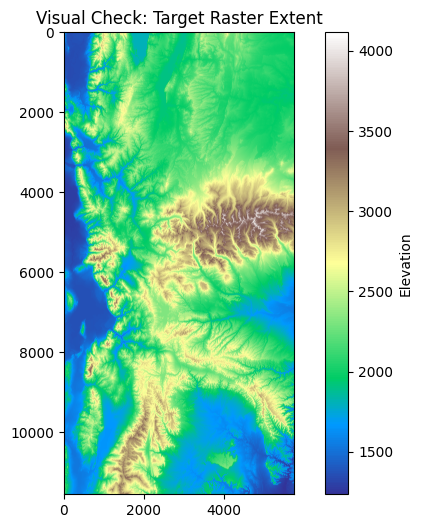

In [ ]:
# --- PARAMETERS ---
input_paths = glob.glob("../data/wurl/usgs_tiles/*.tif")  # Single file or list of files
output_path = "../data/wurl/processed_dem.tif"
target_crs = "EPSG:32143"  # Your desired output CRS
downsample_factor = 1.0  # 1.0 to skip

def largest_inner_rectangle(mask):
    h, w = mask.shape
    heights = np.zeros(w + 1, dtype=np.int32)
    best_rmin = best_cmin = best_rmax = best_cmax = 0
    max_area = 0
    for r in range(h):
        for c in range(w):
            if mask[r, c]:
                heights[c] += 1
            else:
                heights[c] = 0
        stack = [-1]
        for c in range(w + 1):
            while heights[c] < heights[stack[-1]]:
                h_val = heights[stack.pop()]
                left = stack[-1] + 1
                width = c - left
                area = h_val * width
                if area > max_area:
                    max_area = area
                    best_rmin = r - h_val + 1
                    best_cmin = left
                    best_rmax = r + 1
                    best_cmax = c
            stack.append(c)
    return best_rmin, best_cmin, best_rmax, best_cmax

opened_files = []
try:
    # 1. Mosaic / Load
    if len(input_paths) == 1:
        src = rasterio.open(input_paths[0])
        opened_files.append(src)
    else:
        opened_files = [rasterio.open(p) for p in input_paths]
        mosaic_array, mosaic_transform = merge(opened_files)
        profile = opened_files[0].profile.copy()
        profile.update({"height": mosaic_array.shape[1], "width": mosaic_array.shape[2], "transform": mosaic_transform})
        memfile = MemoryFile()
        src = memfile.open(**profile)
        src.write(mosaic_array)
        opened_files.extend([memfile, src])

    # 2. Downsample (optional)
    if downsample_factor != 1.0:
        new_h, new_w = int(src.height / downsample_factor), int(src.width / downsample_factor)
        ds_transform = src.transform * src.transform.scale((src.width / new_w), (src.height / new_h))
        ds_data = src.read(out_shape=(src.count, new_h, new_w), resampling=Resampling.bilinear)
        profile = src.profile.copy()
        profile.update({"height": new_h, "width": new_w, "transform": ds_transform})
        memfile_ds = MemoryFile()
        src = memfile_ds.open(**profile)
        src.write(ds_data)
        opened_files.extend([memfile_ds, src])

    # 3. Reproject
    dst_crs = rasterio.crs.CRS.from_string(target_crs)
    transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
    profile = src.profile.copy()
    profile.update({'crs': dst_crs, 'transform': transform, 'width': width, 'height': height})
    memfile_repr = MemoryFile()
    src_repr = memfile_repr.open(**profile)
    for i in range(1, src.count + 1):
        reproject(rasterio.band(src, i), rasterio.band(src_repr, i), src_transform=src.transform, 
                  src_crs=src.crs, dst_transform=transform, dst_crs=dst_crs, resampling=Resampling.bilinear)
    opened_files.extend([memfile_repr, src_repr])

    # 4. Crop to largest valid rectangle
    band = src_repr.read(1)
    nodata = src_repr.nodata if src_repr.nodata is not None else 0
    valid_mask = (band != nodata)
    total_nodata_pre = int(np.sum(~valid_mask))
    print(f"Pre-crop dimensions: {src_repr.width}x{src_repr.height}")
    print(f"Pre-crop CRS: {src_repr.crs}")
    print(f"NoData cells before crop: {total_nodata_pre}")

    rmin, cmin, rmax, cmax = largest_inner_rectangle(valid_mask)
    window = Window(cmin, rmin, cmax - cmin, rmax - rmin)
    cropped_data = src_repr.read(window=window)
    cropped_transform = rasterio.windows.transform(window, src_repr.transform)

    # 5. Save Output
    final_profile = src_repr.profile.copy()
    final_profile.update({"height": cropped_data.shape[1], "width": cropped_data.shape[2], "transform": cropped_transform})
    with rasterio.open(output_path, "w", **final_profile) as dst:
        dst.write(cropped_data)

    print(f"Output dimensions: {cropped_data.shape[2]}x{cropped_data.shape[1]}")
    print(f"Output CRS: {dst_crs}")
    output_nodata = int(np.sum(cropped_data[0] == nodata))
    print(f"NoData cells in output: {output_nodata}")
    print("Processing completed successfully.")

    # --- LANDFIRE REQUEST PARAMETERS ---
    print("\n" + "="*30)
    print("LANDFIRE REQUEST PARAMETERS")
    print("="*30)
    
    # Calculate WGS84 Bounding Box (for AOI)
    from rasterio.warp import transform_bounds
    wgs84_bounds = transform_bounds(src_repr.crs, 'EPSG:4326', *src_repr.bounds)
    aoi_string = f"{wgs84_bounds[0]} {wgs84_bounds[1]} {wgs84_bounds[2]} {wgs84_bounds[3]}"
    
    print(f"Layer List: LF2024_EVC;LF2020_BPS")
    print(f"AOI (W S E N): {aoi_string}")
    print(f"Output Projection (WKID): {dst_crs.to_epsg()}")
    print("Resample Resolution: [Leave blank for default 30m]")
    print("="*30 + "\n")

    # Optional: Quick Visual Check
    plt.figure(figsize=(8, 6))
    plt.imshow(cropped_data[0], cmap='terrain')
    plt.title("Visual Check: Target Raster Extent")
    plt.colorbar(label='Elevation')
    plt.show()

finally:
    for f in reversed(opened_files):
        try: f.close()
        except: pass

## Gather Accompanying Layers

### Bare Earth Color

Use the USDA NRCS Soil Colors of the United States dataset. Reproject, resample, and crop to match DEM.

In [10]:
# --- PARAMETERS ---
template_path = "../data/wurl/processed_dem.tif"
source_path = "../data/soil_color/US-soil-color-010cm-gNATSGO-highres.tif"
output_path = "../data/wurl/aligned_soil_raster.tif"

# --- PROCESSING ---
with rasterio.open(template_path) as template:
    # Extract the exact target profile metrics from your template TIF
    target_profile = template.profile.copy()
    target_crs = template.crs
    target_transform = template.transform
    target_width = template.width
    target_height = template.height
    
    # Ensure the output profile matches your template's data layout
    # Classification rasters typically use integers (e.g., uint8 or uint16)
    # We read the data type directly from your source class raster
    with rasterio.open(source_path) as source:
        source_dtype = source.dtypes[0]
        source_nodata = source.nodata if source.nodata is not None else 0
        
        target_profile.update({
            'dtype': source_dtype,
            'nodata': source_nodata,
            'count': 1
        })

        # Create the output file with the template's exact configurations
        with rasterio.open(output_path, 'w', **target_profile) as dst:
            
            print(f"Resampling categorical raster: {source_path}...")
            print(f"Target dimensions: {target_width}x{target_height}")
            print(f"Data Type preserved: {source_dtype}")

            # Reproject/Resample the data manually
            reproject(
                source=rasterio.band(source, 1),
                destination=rasterio.band(dst, 1),
                src_transform=source.transform,
                src_crs=source.crs,
                dst_transform=target_transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest,
                dst_nodata=source_nodata
            )
            
print(f"SUCCESS: Pixel-perfect aligned class file written to {output_path}")

Resampling categorical raster: ../data/soil_color/US-soil-color-010cm-gNATSGO-highres.tif...
Target dimensions: 5768x11548
Data Type preserved: uint16
SUCCESS: Pixel-perfect aligned class file written to ../data/wurl/aligned_soil_raster.tif


### Trail

This step is entirely optional. But if you have a GPX of a trail you'd like to include, we need to turn it into a mask for land cover and a polyline for rendering.

In [ ]:
# --- PARAMETERS ---
DEM_PATH = "../data/wurl/processed_dem.tif"
GPX_PATH = "../data/trails/WURL_Wasatch_Ultimate_Ridge_Linkup.gpx"
TRAIL_MASK_OUT = "../data/wurl/trail_mask.tif"
TRAIL_LINE_OUT = "../data/wurl/trail_line.tif"
CORRIDOR_WIDTH_PX = 2

# --- PROCESSING ---
# Step 1: Parse GPX track
with open(GPX_PATH) as f:
    gpx = gpxpy.parse(f)

points = []
for track in gpx.tracks:
    for segment in track.segments:
        for pt in segment.points:
            points.append((pt.latitude, pt.longitude))

if not points:
    raise ValueError("No track points found in GPX.")

# Step 2: Open DEM for CRS / transform / shape
with rasterio.open(DEM_PATH) as src:
    dst_crs = src.crs
    dem_transform = src.transform
    height, width = src.height, src.width

# Step 3: Convert WGS84 coordinates to DEM projected CRS
project = pyproj.Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
trail_utm = np.array([project.transform(lon, lat) for lat, lon in points])

# Step 4: Resample trail to one vertex per DEM pixel
dem_res_m = abs(dem_transform[0])
trail_line_geom = LineString(trail_utm)
resampled = []
for d in np.arange(0, trail_line_geom.length, dem_res_m):
    pt = trail_line_geom.interpolate(d)
    resampled.append((pt.x, pt.y))
last_pt = (trail_utm[-1, 0], trail_utm[-1, 1])
if np.linalg.norm(np.array(resampled[-1]) - np.array(last_pt)) > dem_res_m * 0.5:
    resampled.append(last_pt)
trail_line_geom = LineString(resampled)

# Step 5: Rasterize 2-pixel-wide corridor -> bare ground mask input
corridor_width_m = CORRIDOR_WIDTH_PX * dem_res_m
corridor = trail_line_geom.buffer(corridor_width_m, cap_style=2, join_style=2)
trail_mask = rasterize(
    [(corridor, 1)],
    out_shape=(height, width),
    transform=dem_transform,
    default_value=0,
    dtype=np.uint8
)
with rasterio.open(TRAIL_MASK_OUT, "w",
    driver="GTiff", height=height, width=width, count=1,
    dtype=np.uint8, crs=dst_crs, transform=dem_transform) as dst:
    dst.write(trail_mask, 1)

# Step 6: Rasterize centerline at 1-pixel-wide by mapping each vertex to its DEM cell.
# No buffer - one vertex per pixel gives a naturally thin line.
trail_line_raster = np.zeros((height, width), dtype=np.uint8)
inv_transform = ~dem_transform
for pt in trail_line_geom.coords:
    col, row = inv_transform * pt
    col, row = int(round(col)), int(round(row))
    if 0 <= row < height and 0 <= col < width:
        trail_line_raster[row, col] = 1

with rasterio.open(TRAIL_LINE_OUT, "w",
    driver="GTiff", height=height, width=width, count=1,
    dtype=np.uint8, crs=dst_crs, transform=dem_transform) as dst:
    dst.write(trail_line_raster, 1)

print(f"Trail mask ({TRAIL_MASK_OUT}): {int(np.sum(trail_mask))} corridor pixels.")
print(f"Trail line ({TRAIL_LINE_OUT}): {int(np.sum(trail_line_raster))} line pixels.")


### Land Cover

Go to https://lfps.usgs.gov/ using the LANDFIRE request parameters. Then align below.

In [3]:
# --- PARAMETERS ---
template_path = "../data/wurl/processed_dem.tif"
source_path = "../data/wurl/landfire_bundle.tif"  # Path to the downloaded multi-band LANDFIRE TIF
output_templates = {
    "EVC": "../data/wurl/aligned_EVC.tif",
    "BPS": "../data/wurl/aligned_BPS.tif"
}

# Mapping layer names to their respective band index in the source TIF
band_mapping = {
    "EVC": 1,
    "BPS": 2
}

# --- PROCESSING ---
with rasterio.open(template_path) as template:
    # Extract the exact target profile metrics from your template TIF
    target_profile = template.profile.copy()
    target_crs = template.crs
    target_transform = template.transform
    target_width = template.width
    target_height = template.height
    
    with rasterio.open(source_path) as source:
        # Loop through each layer to resample, extract, and align them from their respective bands
        for layer_name, band_index in band_mapping.items():
            output_path = output_templates[layer_name]
            
            # Read metadata specifics for the current band
            source_dtype = source.dtypes[band_index - 1]
            source_nodata = source.nodata if source.nodata is not None else 0
            
            target_profile.update({
                'dtype': source_dtype,
                'nodata': source_nodata,
                'count': 1
            })

            # Create the separate output file with the template's exact configurations
            with rasterio.open(output_path, 'w', **target_profile) as dst:
                
                print(f"Resampling categorical raster ({layer_name} from Band {band_index}): {source_path}...")
                print(f"Target dimensions: {target_width}x{target_height}")
                print(f"Data Type preserved: {source_dtype}")

                # Reproject/Resample the specific band manually
                reproject(
                    source=rasterio.band(source, band_index),
                    destination=rasterio.band(dst, 1),
                    src_transform=source.transform,
                    src_crs=source.crs,
                    dst_transform=target_transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest, # Nearest neighbor preserves categorical land cover IDs
                    dst_nodata=source_nodata
                )
                
            print(f"SUCCESS: Pixel-perfect aligned {layer_name} file written to {output_path}\n")

print("All bands extracted and aligned successfully.")

Resampling categorical raster (EVC from Band 1): ../data/wurl/landfire_bundle.tif...
Target dimensions: 5768x11548
Data Type preserved: int16
SUCCESS: Pixel-perfect aligned EVC file written to ../data/wurl/aligned_EVC.tif

Resampling categorical raster (BPS from Band 2): ../data/wurl/landfire_bundle.tif...
Target dimensions: 5768x11548
Data Type preserved: int16
SUCCESS: Pixel-perfect aligned BPS file written to ../data/wurl/aligned_BPS.tif

All bands extracted and aligned successfully.


Primary output: <code>evc_predicted.tif</code> (int16, full LANDFIRE EVC class code for every pixel). Also exports <code>bare_ground_mask.tif</code> (uint8, class 31=Barren) as a convenience. RF trained on aligned EVC + BPS + DEM derivatives. See the painterly engine for per-class lookup.


In [ ]:
# --- PARAMETERS ---
DEM_PATH = "../data/wurl/processed_dem.tif"
EVC_PATH = "../data/wurl/aligned_EVC.tif"
BPS_PATH = "../data/wurl/aligned_BPS.tif"
TRAIL_MASK_PATH = "../data/wurl/trail_mask.tif"

EVC_PRED_OUT = "../data/wurl/evc_predicted.tif"
BARE_MASK_OUT = "../data/wurl/bare_ground_mask.tif"

# RF params
N_TREES = 100
MAX_DEPTH = 20
MAX_TRAIN_SAMPLES = 2_000_000
RANDOM_STATE = 42

# EVC class 31 = Barren
BARE_EVC_CLASSES = {31}

# Classes to exclude from training (human-modified)
HUMAN_CLASSES = {
    13, 14, 15, 16, 17,  # Developed-Upland
    18, 19,               # Developed-Wetland
    20, 21, 22, 23, 24,  # Developed-General through High
    25,                   # Developed-Roads
    32,                   # Quarries
    60, 61, 62, 63, 64, 65, 66, 67, 68, 69,  # NASS Agriculture
    80, 81, 82, 83, 84, 85,  # Agriculture / Urban grasses
}

EVC_NODATA = -9999

# Blur sigma per predictor (pixels at ~30m)
BLUR = {"elev": 3, "slope": 2, "northness": 2,
        "tpi_100": 3, "tpi_500": 4, "curvature": 2}

# --- 1. LOAD DEM ---
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype(np.float64)
    profile = src.profile.copy()
    dem_transform = src.transform
    crs = src.crs
    res = abs(dem_transform[0])
    nodata = src.nodata
    valid = dem != nodata if nodata is not None else np.ones_like(dem, dtype=bool)
    dem[~valid] = np.nan
h, w = dem.shape
print(f"DEM: {w}x{h}, {res:.1f}m resolution")

# --- 2. LOAD / ALIGN EVC & BPS ---
def align_to_dem(src_path):
    with rasterio.open(src_path) as src:
        arr = src.read(1, out_shape=(h, w), resampling=Resampling.nearest)
    return arr

evc = align_to_dem(EVC_PATH)
bps = align_to_dem(BPS_PATH)
print(f"EVC shape: {evc.shape}, BPS shape: {bps.shape}")

# --- 3. TRAINING MASK: exclude human-modified classes ---
train_mask = (~np.isin(evc, list(HUMAN_CLASSES))
              & (evc != EVC_NODATA) & valid)
train_rows, train_cols = np.where(train_mask)
n_train = len(train_rows)
n_human = int(np.sum(np.isin(evc, list(HUMAN_CLASSES))))
print(f"Human-modified pixels to replace: {n_human:,}")
print(f"Natural training pixels available: {n_train:,}")

# --- 4. DEM DERIVATIVES ---
dem_filled = np.where(np.isnan(dem), np.nanmean(dem), dem)
gx, gy = np.gradient(dem_filled, res, res)
slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))
aspect = np.degrees(np.arctan2(-gy, -gx)) % 360
northness = np.cos(np.radians(aspect))
curvature = laplace(dem_filled) * res**2
tpi_100 = dem_filled - gaussian_filter(dem_filled, sigma=100.0/res)
tpi_500 = dem_filled - gaussian_filter(dem_filled, sigma=500.0/res)
print("Derivatives computed.")

# --- 5. BLUR PREDICTORS ---
def blur(arr, sigma):
    if sigma <= 0: return arr.copy()
    return gaussian_filter(arr, sigma=sigma, mode="reflect")
elev_b   = blur(dem_filled, BLUR["elev"])
slope_b  = blur(slope, BLUR["slope"])
north_b  = blur(northness, BLUR["northness"])
aspect_b = blur(aspect, BLUR["northness"])
curv_b   = blur(curvature, BLUR["curvature"])
tpi100_b = blur(tpi_100, BLUR["tpi_100"])
tpi500_b = blur(tpi_500, BLUR["tpi_500"])
print("Predictors blurred.")

# --- 6. ENVIRONMENTAL FIELDS ---
def zscore(x):
    m = np.nanmean(x)
    s = np.nanstd(x)
    return (x - m) / s if s > 0 else np.zeros_like(x)
exposure_raw = (0.7 * zscore(tpi500_b) + 0.3 * zscore(tpi100_b) +
                0.3 * np.maximum(curv_b, 0) / (np.nanstd(curv_b) + 1e-6))
exposure = zscore(exposure_raw)
aspect_rad = np.radians(aspect_b)
westness = -np.sin(aspect_rad)
orographic = (0.5 * zscore(westness) + 0.5 * zscore(tpi500_b))
moisture = np.clip(0.5 + 0.5 * orographic, 0, 1)
print("Environmental fields built.")

# --- 7. BUILD FEATURE STACK ---
x_coords = np.tile(np.arange(w, dtype=np.float32), (h, 1))
y_coords = np.tile(np.arange(h, dtype=np.float32).reshape(-1, 1), (1, w))
features = np.stack([
    bps.astype(np.float32),
    zscore(elev_b).astype(np.float32),
    zscore(slope_b).astype(np.float32),
    north_b.astype(np.float32),
    zscore(curv_b).astype(np.float32),
    zscore(tpi100_b).astype(np.float32),
    zscore(tpi500_b).astype(np.float32),
    exposure.astype(np.float32),
    moisture.astype(np.float32),
    x_coords / w,
    y_coords / h,
], axis=-1)
n_features = features.shape[-1]
print(f"Feature stack: {n_features} features")

# --- 8. SAMPLE + TRAIN RF ---
if n_train > MAX_TRAIN_SAMPLES:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(n_train, MAX_TRAIN_SAMPLES, replace=False)
    train_rows, train_cols = train_rows[idx], train_cols[idx]
    print(f"Subsampled to {MAX_TRAIN_SAMPLES:,} training pixels.")

X_train = features[train_rows, train_cols, :]
y_train = evc[train_rows, train_cols]

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=N_TREES, max_depth=MAX_DEPTH,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
print("RF training complete.")

# --- 9. PREDICT ONLY HUMAN-MODIFIED PIXELS (chunked to avoid 7 GB proba) ---
human_rows, human_cols = np.where(np.isin(evc, list(HUMAN_CLASSES)))
n_human = len(human_rows)
pred = evc.copy()
print(f"Predicting {n_human:,} human-modified pixels (chunked)...")
human_features = features[human_rows, human_cols, :]
chunk = 100_000
for start in range(0, n_human, chunk):
    end = min(start + chunk, n_human)
    pred[human_rows[start:end], human_cols[start:end]] = rf.predict(human_features[start:end])
print("Prediction complete.")

# --- 10. POST-PROCESS ---
pred[~valid] = -9999
bare_mask = np.isin(pred, list(BARE_EVC_CLASSES)).astype(np.uint8)

print(f"Predicted EVC classes: {len(np.unique(pred))}")
print(f"Bare ground pixels: {int(np.sum(bare_mask))} ({100.0*np.sum(bare_mask)/bare_mask.size:.1f}%)")

# --- 11. TRAIL CLEARANCE ---
if os.path.exists(TRAIL_MASK_PATH):
    with rasterio.open(TRAIL_MASK_PATH) as t:
        trail = t.read(1) == 1
    bare_mask[trail] = 1
    pred[trail] = 31
    print(f"Trail clearance applied: {int(np.sum(trail))} pixels.")
else:
    print("No trail mask found, skipping trail clearance.")

# --- 12. EXPORT ---
out_profile_i16 = profile.copy()
out_profile_i16.update(dtype="int16", count=1, nodata=-9999)
with rasterio.open(EVC_PRED_OUT, "w", **out_profile_i16) as dst:
    dst.write(pred.astype(np.int16), 1)
print(f"Exported: {EVC_PRED_OUT}")

out_profile_u8 = profile.copy()
out_profile_u8.update(dtype="uint8", count=1, nodata=0)
with rasterio.open(BARE_MASK_OUT, "w", **out_profile_u8) as dst:
    dst.write(bare_mask, 1)
print(f"Exported: {BARE_MASK_OUT}")

# --- 13. VISUAL SANITY CHECK ---
step = max(1, h // 1000)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
im0 = axes[0].imshow(pred[::step, ::step], cmap="tab20", interpolation="nearest")
axes[0].set_title("Predicted EVC Class")
plt.colorbar(im0, ax=axes[0], fraction=0.046, shrink=0.7)
axes[1].imshow(bare_mask[::step, ::step], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Bare Ground Mask")
plt.tight_layout()
plt.show()
print("\nLand cover generation complete.")


### Water

Rasterize waterbodies and streams (Strahler order &gt; 3) from NHD to a water mask. Overlaid onto <code>evc_predicted.tif</code> in the next cell.


In [ ]:
# --- PARAMETERS ---
DEM_PATH = "../data/wurl/processed_dem.tif"
NHD_GDB = "../data/hydr48m010g.gdb"
WATER_MASK_OUT = "../data/wurl/water_mask.tif"
BUFFER_DIST_M = 30
MIN_STRAHLER = 4

# --- PROCESSING ---
import fiona
from shapely.geometry import box, shape
from shapely.ops import transform
from rasterio.features import rasterize
import pyproj

# Step 1: Open DEM
with rasterio.open(DEM_PATH) as src:
    dst_crs = src.crs
    dem_transform = src.transform
    height, width = src.height, src.width
    dem_bounds = src.bounds
dem_box_utm = box(*dem_bounds)

# Step 2: Read lake polygons, using NHD-native CRS for intersection
lake_polys = []
with fiona.open(NHD_GDB, layer="Waterbody") as src:
    nhd_crs = src.crs
    project_to_nhd = pyproj.Transformer.from_crs(dst_crs, nhd_crs, always_xy=True).transform
    dem_box_nhd = transform(project_to_nhd, dem_box_utm)
    for feat in src:
        geom = shape(feat.geometry)
        if geom.intersects(dem_box_nhd):
            if geom.geom_type == "MultiPolygon":
                lake_polys.extend(list(geom.geoms))
            else:
                lake_polys.append(geom)
print(f"Read {len(lake_polys)} lake polygons from NHD.")

# Step 3: Read streams, filter by Strahler order
river_lines = []
n_skipped = 0
with fiona.open(NHD_GDB, layer="Stream") as src:
    for feat in src:
        if feat['properties']['Strahler'] < MIN_STRAHLER:
            n_skipped += 1
            continue
        geom = shape(feat.geometry)
        if geom.intersects(dem_box_nhd):
            if geom.geom_type == "MultiLineString":
                river_lines.extend(list(geom.geoms))
            else:
                river_lines.append(geom)
print(f"Read {len(river_lines)} river segments (Strahler >= {MIN_STRAHLER}), skipped {n_skipped} lower-order.")

# Step 4: Reproject to DEM CRS
project_to_dem = pyproj.Transformer.from_crs(nhd_crs, dst_crs, always_xy=True).transform
lake_polys = [transform(project_to_dem, p) for p in lake_polys]
river_lines = [transform(project_to_dem, l) for l in river_lines]

# Step 5: Clip to DEM bounds
lake_polys = [p.intersection(dem_box_utm) for p in lake_polys if p.intersects(dem_box_utm)]
river_lines = [l.intersection(dem_box_utm) for l in river_lines if l.intersects(dem_box_utm)]

# Step 6: Merge lakes
merged = []
for p in lake_polys:
    if not p.is_valid:
        p = p.buffer(0)
    absorbed = False
    for i, mp in enumerate(merged):
        if mp.intersects(p):
            merged[i] = mp.union(p)
            absorbed = True
            break
    if not absorbed:
        merged.append(p)
lake_polys = merged
print(f"After merge: {len(lake_polys)} lake polygons.")

# Step 7: Buffer rivers
river_buffered = [l.buffer(BUFFER_DIST_M, cap_style=2, join_style=2) for l in river_lines]

# Step 8: Rasterize
water_geoms = [(p, 1) for p in lake_polys] + [(b, 1) for b in river_buffered]
if water_geoms:
    water_mask = rasterize(
        water_geoms, out_shape=(height, width),
        transform=dem_transform, default_value=0, dtype=np.float32
    )
else:
    water_mask = np.zeros((height, width), dtype=np.float32)

# Step 9: Save
with rasterio.open(WATER_MASK_OUT, "w",
    driver="GTiff", height=height, width=width, count=1,
    dtype=np.float32, crs=dst_crs, transform=dem_transform) as dst:
    dst.write(water_mask, 1)

water_px = int(np.sum(water_mask > 0.5))
print(f"Water mask: {WATER_MASK_OUT}")
print(f"  Water pixels: {water_px}")


### Overlay Water onto Unified Landcover


In [ ]:
# --- PARAMETERS ---
EVC_PATH = "../data/wurl/evc_predicted.tif"
WATER_MASK_PATH = "../data/wurl/water_mask.tif"
UNIFIED_OUT = "../data/wurl/unified_landcover.tif"
WATER_CLASS = 11  # Open Water in EVC schema
WATER_THRESH = 0.5  # water_mask > this = water

# --- PROCESSING ---
with rasterio.open(EVC_PATH) as src:
    lc = src.read(1)
    profile = src.profile.copy()

with rasterio.open(WATER_MASK_PATH) as src:
    water = src.read(1)

water_binary = water > WATER_THRESH
n_overlay = int(np.sum(water_binary))
lc[water_binary] = WATER_CLASS

print(f"Overlaid {n_overlay:,} water pixels onto landcover.")

profile.update(dtype="int16", count=1, nodata=-9999)
with rasterio.open(UNIFIED_OUT, "w", **profile) as dst:
    dst.write(lc.astype(np.int16), 1)
print(f"Exported: {UNIFIED_OUT}")


Now we create our base ply. We don't add anything to it yet, because Blender sometimes overwrites custom attributes.

In [3]:
# --- PARAMETERS ---
DEM_TIF_PATH = "../data/wurl/processed_dem.tif"
OUTPUT_PLY_PATH = "../data/wurl/base.ply"

# --- HELPER FUNCTIONS ---
def write_flat_ply(path, vertices_xyz, faces_0idx):
    """Writes a clean binary little-endian PLY file of the unwarped terrain using pure triangles."""
    n_verts = len(vertices_xyz)
    n_faces = len(faces_0idx)

    header = (
        f"ply\n"
        f"format binary_little_endian 1.0\n"
        f"element vertex {n_verts}\n"
        f"property float x\nproperty float y\nproperty float z\n"
        f"element face {n_faces}\n"
        f"property list uchar uint vertex_indices\n"
        f"end_header\n"
    ).encode("ascii")

    # Pack structure for coordinates
    vert_dtype = np.dtype([("x", "<f4"), ("y", "<f4"), ("z", "<f4")])
    vert_struct = np.empty(n_verts, dtype=vert_dtype)
    vert_struct["x"] = vertices_xyz[:, 0]
    vert_struct["y"] = vertices_xyz[:, 1]
    vert_struct["z"] = vertices_xyz[:, 2]

    # Pack structure for triangle faces (Fixed 3 indices per row = 13 bytes total per face)
    face_dtype = np.dtype([("count", "u1"), ("v0", "<u4"), ("v1", "<u4"), ("v2", "<u4")])
    face_struct = np.empty(n_faces, dtype=face_dtype)
    face_struct["count"] = 3
    face_struct["v0"] = faces_0idx[:, 0]
    face_struct["v1"] = faces_0idx[:, 1]
    face_struct["v2"] = faces_0idx[:, 2]

    # Ensure output directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    with open(path, "wb") as f:
        f.write(header)
        f.write(vert_struct.tobytes())
        f.write(face_struct.tobytes())
    print(f"\nSuccessfully generated clean triangle terrain sheet: {path}")

# --- PROCESSING ---
print(f"Reading source GeoTIFF dataset: {DEM_TIF_PATH}...")

with rasterio.open(DEM_TIF_PATH) as src:
    out_h = src.height
    out_w = src.width
    
    # Read elevation band directly
    elevation = src.read(1)
    
    # Create the strict validation mask across the full dataset
    nodata_val = src.nodata if src.nodata is not None else -9999
    valid_mask = (elevation != nodata_val) & (elevation > -9000)
    flat_valid = valid_mask.ravel()
    
    # Generate full exact pixel index grids
    cols, rows = np.meshgrid(np.arange(out_w), np.arange(out_h))
    
    # Extract native metric coordinates from the projected CRS
    xs, ys = rasterio.transform.xy(src.transform, rows, cols)
    x_metric = np.array(xs).reshape(out_h, out_w)
    y_metric = np.array(ys).reshape(out_h, out_w)

print(f"Grid size pulled: {out_w}x{out_h} ({out_w * out_h} points)")

# Anchor local space around the center of the full bounding box
x_center = x_metric[out_h // 2, out_w // 2]
y_center = y_metric[out_h // 2, out_w // 2]

x_local = x_metric - x_center
y_local = y_metric - y_center
z_local = elevation * 2.5  # Native elevation exaggeration/scale factor

# Scale geometry down uniformly to fit inside standard scene layouts
SCALE_FACTOR = 0.001 
X_scaled = x_local * SCALE_FACTOR
Y_scaled = y_local * SCALE_FACTOR
Z_scaled = z_local * SCALE_FACTOR

# Compile the 1D structured vertex arrays
flat_raw_pts = np.column_stack((X_scaled.ravel(), Y_scaled.ravel(), Z_scaled.ravel()))

# Build base grid coordinate structures
ri, ci = np.mgrid[0:out_h-1, 0:out_w-1]
tl = ri * out_w + ci
tr = tl + 1
bl = (ri + 1) * out_w + ci
br = bl + 1

# Explicitly divide each grid quad into two uniform triangles
tri1 = np.column_stack((tl.ravel(), bl.ravel(), br.ravel()))
tri2 = np.column_stack((tl.ravel(), br.ravel(), tr.ravel()))
all_triangles = np.vstack((tri1, tri2))

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 1: Raw Triangulation Properties
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating raw triangulated grid...")
expected_quads = (out_h - 1) * (out_w - 1)
expected_tris = expected_quads * 2
print(f" -> Mathematical Expected Triangles (Full Grid): {expected_tris:,}")
print(f" -> Generated Triangles Matrix Shape: {all_triangles.shape}")
print(f" -> Face index columns per row: {all_triangles.shape[1]} (Expected: 3)")
assert all_triangles.shape[1] == 3, "CRITICAL ERROR: Generated faces are not triangles!"
assert all_triangles.shape[0] == expected_tris, "CRITICAL ERROR: Triangle pool mismatch!"

# Keep only triangles where EVERY single corner points to a valid data pixel
face_mask = (flat_valid[all_triangles[:, 0]] & 
             flat_valid[all_triangles[:, 1]] & 
             flat_valid[all_triangles[:, 2]])
kept_triangles = all_triangles[face_mask]

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 2: Mask Filters & Data Bounds
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating mask filter calculations...")
dropped_faces = expected_tris - len(kept_triangles)
print(f" -> Total valid faces retained: {len(kept_triangles):,}")
print(f" -> Total NoData faces dropped: {dropped_faces:,}")

# Compact: Extract only the unique vertices that are actually used by valid faces
used_verts = np.unique(kept_triangles)
compact_pts = flat_raw_pts[used_verts]

# Remap old vertex indices to the new compacted vertex array indices
remap = np.empty(len(flat_raw_pts), dtype=np.int64)
remap[used_verts] = np.arange(len(used_verts))
compact_triangles = remap[kept_triangles].astype(np.uint32)

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 3: Compacted Mesh Integrity Check
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating final mesh compaction array boundaries...")
min_idx = np.min(compact_triangles)
max_idx = np.max(compact_triangles)
allowed_max = len(compact_pts) - 1

print(f" -> Total Unique Vertices Allocated: {len(compact_pts):,}")
print(f" -> Compacted Face Indices Range: [{min_idx} to {max_idx}]")
print(f" -> Max Permitted Vertex Index Pointer: {allowed_max}")

if max_idx > allowed_max:
    print(f" -> [CRITICAL WARNING] Out-of-bounds indices are present before exporting!")
else:
    print(" -> [SUCCESS] Index range perfectly aligned. No out-of-bounds pointers detected.")

assert min_idx >= 0, "CRITICAL ERROR: Negative index found in topology!"
assert max_idx <= allowed_max, "CRITICAL ERROR: Topology references unallocated vertex index!"

# Save output pure surface mesh file
write_flat_ply(OUTPUT_PLY_PATH, compact_pts, compact_triangles)

Reading source GeoTIFF dataset: ../data/wurl/processed_dem.tif...
Grid size pulled: 4673x6084 (28430532 points)

[VALIDATION] Validating raw triangulated grid...
 -> Mathematical Expected Triangles (Full Grid): 56,839,552
 -> Generated Triangles Matrix Shape: (56839552, 3)
 -> Face index columns per row: 3 (Expected: 3)

[VALIDATION] Validating mask filter calculations...
 -> Total valid faces retained: 56,362,267
 -> Total NoData faces dropped: 477,285

[VALIDATION] Validating final mesh compaction array boundaries...
 -> Total Unique Vertices Allocated: 28,191,872
 -> Compacted Face Indices Range: [0 to 28191871]
 -> Max Permitted Vertex Index Pointer: 28191871
 -> [SUCCESS] Index range perfectly aligned. No out-of-bounds pointers detected.

Successfully generated clean triangle terrain sheet: ../data/wurl/base.ply


## 2.5D Shadow & AO Computation (replaces Blender)


Ray-marched shadows and topographic openness computed directly on the DEM heightfield. No mesh, no tiles, no Blender subprocess. See the next code cell.


In [ ]:
# === 2.5D SHADOW + AO BAKE ===
# Ray-marched directional shadows + topographic openness on the DEM heightfield.
# To be implemented. Replaces the entire Blender subprocess pipeline.
# Input:  ../data/wurl/processed_dem.tif
# Output: ../data/wurl/shadow_ao.tif
print("2.5D shadow + AO bake -- not yet implemented.")
